# W02 RF Benchmark

**Platform:** Aido Rover  
**Seed:** 42  
**Sampling rate:** 10 Hz


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import time

DATA_DIR = Path('../data')
TEMP_DIR = DATA_DIR / 'temp'
SEED     = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Load data from W02_Preprocessing_Pipeline.ipynb ─────────────────
X_tr_s   = np.load(TEMP_DIR / 'X_tr_s.npy')
X_va_s   = np.load(TEMP_DIR / 'X_va_s.npy')
X_te_s   = np.load(TEMP_DIR / 'X_te_s.npy')
y_tr_s   = np.load(TEMP_DIR / 'y_tr_s.npy')
y_va_s   = np.load(TEMP_DIR / 'y_va_s.npy')
y_te_s   = np.load(TEMP_DIR / 'y_te_s.npy')
best_idx = np.load(TEMP_DIR / 'best_idx.npy')

### RF Training

Grid search over `n_estimators ∈ {50, 100, 200}` × `max_depth ∈ {None, 5, 10, 20}` (12 combos, 5-fold CV, scoring = F1).  
`class_weight='balanced'` compensates for the 85/15 normal/anomaly imbalance.  
Trained and evaluated on the top-K PCA components.

Best hyperparameters : {'max_depth': 20, 'n_estimators': 50}
CV best F1           : 0.8279
Train time           : 7.22 s
Inference / 1,000 samples : 5.18 ms

── Validation ──
              precision    recall  f1-score   support

      Normal     0.9786    0.9570    0.9677      1908
     Anomaly     0.7819    0.8802    0.8282       334

    accuracy                         0.9456      2242
   macro avg     0.8802    0.9186    0.8979      2242
weighted avg     0.9493    0.9456    0.9469      2242

AUC-ROC : 0.9702

── Test ──
              precision    recall  f1-score   support

      Normal     0.9844    0.9576    0.9708      1909
     Anomaly     0.7902    0.9132    0.8472       334

    accuracy                         0.9510      2243
   macro avg     0.8873    0.9354    0.9090      2243
weighted avg     0.9555    0.9510    0.9524      2243

AUC-ROC : 0.9819


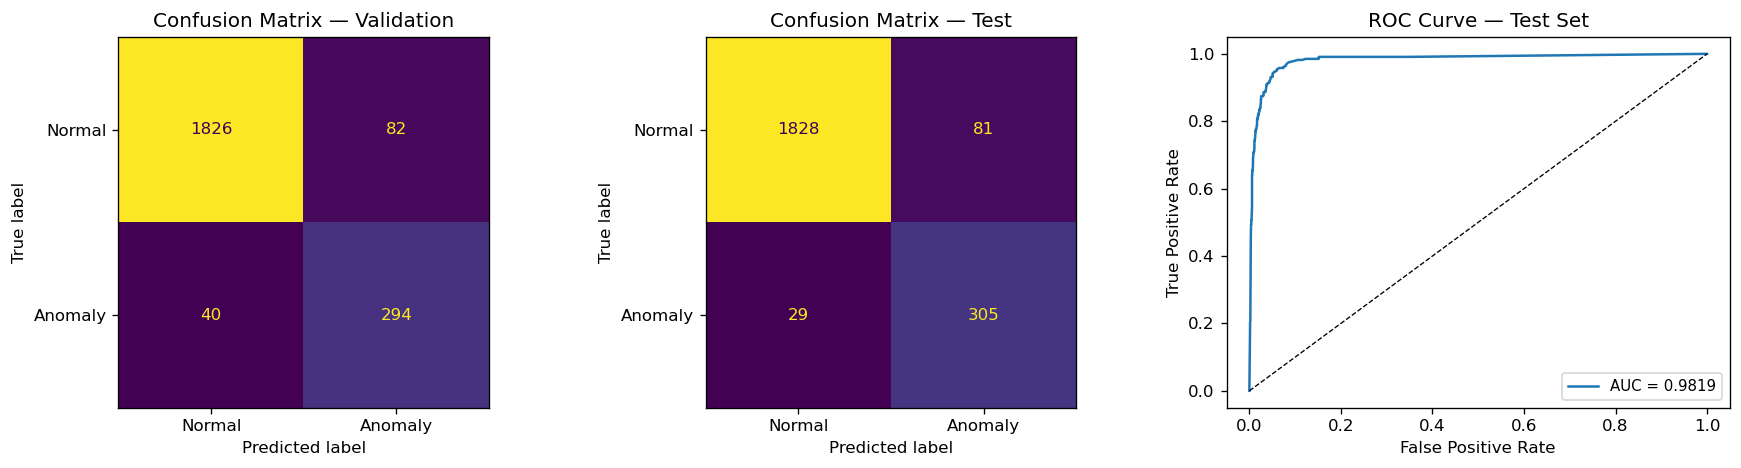

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, f1_score)

# ── Grid search ────────────────────────────────────────────────────────────
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10, 20],
}
rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=1)
gs      = GridSearchCV(rf_base, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)

t_start    = time.perf_counter()
gs.fit(X_tr_s[:, best_idx], y_tr_s)
train_time_s = time.perf_counter() - t_start

best_rf     = gs.best_estimator_
best_params = gs.best_params_

print(f'Best hyperparameters : {best_params}')
print(f'CV best F1           : {gs.best_score_:.4f}')
print(f'Train time           : {train_time_s:.2f} s')

# ── Inference / 1,000 samples (single timing pass) ───────────────────────
x_infer_1k = X_te_s[:1000, best_idx]
_t0 = time.perf_counter()
_ = best_rf.predict(x_infer_1k)
infer_1k_ms = (time.perf_counter() - _t0) * 1000
print(f'Inference / 1,000 samples : {infer_1k_ms:.2f} ms')

# ── Validation evaluation ──────────────────────────────────────────────────
y_va_pred  = best_rf.predict(X_va_s[:, best_idx])
y_va_proba = best_rf.predict_proba(X_va_s[:, best_idx])[:, 1]
auc_va     = roc_auc_score(y_va_s, y_va_proba)

print('\n── Validation ──')
print(classification_report(y_va_s, y_va_pred,
                             target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC : {auc_va:.4f}')

# ── Test evaluation ────────────────────────────────────────────────────────
y_te_pred      = best_rf.predict(X_te_s[:, best_idx])
y_te_proba     = best_rf.predict_proba(X_te_s[:, best_idx])[:, 1]
auc_te         = roc_auc_score(y_te_s, y_te_proba)
test_f1_score  = f1_score(y_te_s, y_te_pred)

print('\n── Test ──')
print(classification_report(y_te_s, y_te_pred,
                             target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC : {auc_te:.4f}')

# ── Confusion matrices + ROC curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_va_s, y_va_pred),
                       display_labels=['Normal', 'Anomaly']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Validation')

ConfusionMatrixDisplay(confusion_matrix(y_te_s, y_te_pred),
                       display_labels=['Normal', 'Anomaly']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Test')

fpr, tpr, _ = roc_curve(y_te_s, y_te_proba)
axes[2].plot(fpr, tpr, lw=1.5, label=f'AUC = {auc_te:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — Test Set')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Latency Benchmarking

Latency benchmarking with timeit (mean of 100 repetitions), test F1 and latency under 100ms.  
Aido Rover real-time constraint: single-sample inference under 100 ms for a 10 Hz stream.

In [9]:
import timeit

N_REPS        = 100
CONSTRAINT_MS = 100.0          # Aido Rover 10 Hz real-time limit
x_single      = X_te_s[0:1, best_idx]
x_batch_1k    = X_te_s[:1000, best_idx]

# ── Single-sample latency (timeit, 100 reps) ───────────────────────────────
single_total  = timeit.timeit(lambda: best_rf.predict(x_single), number=N_REPS)
single_ms     = (single_total / N_REPS) * 1000

# ── 1,000-sample batch latency (timeit, 100 reps) ─────────────────────────
batch_total   = timeit.timeit(lambda: best_rf.predict(x_batch_1k), number=N_REPS)
batch_1k_ms   = (batch_total / N_REPS) * 1000
per_sample_ms = batch_1k_ms / 1000

meets_rt = single_ms < CONSTRAINT_MS

print('── Latency Benchmark ──────────────────')
print(f'  Single-sample inference  : {single_ms:.3f} ms')
print(f'  1,000-sample batch       : {batch_1k_ms:.2f} ms  '
      f'({per_sample_ms:.4f} ms per sample in batch)')
print(f'  Test F1 (anomaly class)  : {test_f1_score:.4f}')
print()
print(f'  Real-time constraint     : < {CONSTRAINT_MS:.0f} ms per sample @ 10 Hz')
print(f'  Single-sample result     : {single_ms:.3f} ms   '
      f'{"PASS" if meets_rt else "FAIL"}')
if meets_rt:
    print(f'  Deployment verdict: RF {best_params} meets the constraint at {single_ms:.3f} ms per sample')
else:
    print()
    print(f'  Deployment verdict: RF {best_params} does NOT meet the 10 Hz constraint')
    print(f'  ({single_ms:.2f} ms > {CONSTRAINT_MS:.0f} ms). Reduce n_estimators or cap max_depth.')

── Latency Benchmark ──────────────────
  Single-sample inference  : 2.106 ms
  1,000-sample batch       : 4.67 ms  (0.0047 ms per sample in batch)
  Test F1 (anomaly class)  : 0.8472

  Real-time constraint     : < 100 ms per sample @ 10 Hz
  Single-sample result     : 2.106 ms   PASS
  Deployment verdict: RF {'max_depth': 20, 'n_estimators': 50} meets the constraint at 2.106 ms per sample
